<a href="https://colab.research.google.com/github/JulianMejia6/IA_2025/blob/main/Vecinos_mas_cercanos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier

clientes = pd.read_csv('/content/creditos.csv')
clientes

,edad,credito,cumplio
0,18,363112,0
1,19,477965,1
2,20,239072,0
3,22,195265,0
4,22,482174,0
...,...,...,...
195,55,100000,0
196,55,523144,0
197,55,543771,0
198,56,285288,0


In [6]:
buenos = clientes[clientes["cumplio"]==1]
malos = clientes[clientes["cumplio"]==0]
buenos, malos

(     edad  credito  cumplio
 1      19   477965        1
 6      23   583565        1
 7      24   100000        1
 8      24   199272        1
 13     25   195341        1
 ..    ...      ...      ...
 187    51   354045        1
 188    51   379188        1
 189    51   396544        1
 190    52   100000        1
 192    53   130475        1
 
 [167 rows x 3 columns],
      edad  credito  cumplio
 0      18   363112        0
 2      20   239072        0
 3      22   195265        0
 4      22   482174        0
 5      23   468815        0
 9      24   246195        0
 10     24   433444        0
 11     25   100000        0
 12     25   161474        0
 40     28   432323        0
 53     29   590394        0
 54     29   595997        0
 56     30   157157        0
 64     31   173752        0
 78     32   588455        0
 93     35   521187        0
 97     36   568053        0
 98     37   299154        0
 113    40   100000        0
 118    40   459974        0
 135    43   498

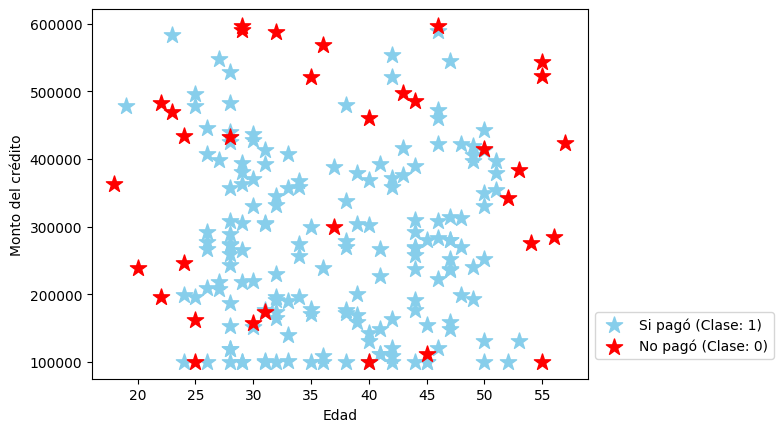

In [9]:
plt.scatter(buenos["edad"], buenos["credito"],
            marker = "*", s=150, color="skyblue",
            label="Si pagó (Clase: 1)")
plt.scatter(malos["edad"], malos["credito"],
            marker = "*", s=150, color="red",
            label="No pagó (Clase: 0)")

plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.2))
plt.show()

In [13]:
datos = clientes[["edad", "credito"]]
clase = clientes["cumplio"]

escalador = preprocessing.MinMaxScaler()

datos = escalador.fit_transform(datos)
datos

array([[0.        , 0.52964444],
       [0.02564103, 0.76084353],
       [0.05128205, 0.27995193],
       [0.1025641 , 0.19176844],
       [0.1025641 , 0.76931624],
       [0.12820513, 0.74242458],
       [0.12820513, 0.97341632],
       [0.15384615, 0.        ],
       [0.15384615, 0.19983453],
       [0.15384615, 0.29429053],
       [0.15384615, 0.67122276],
       [0.17948718, 0.        ],
       [0.17948718, 0.12374716],
       [0.17948718, 0.19192143],
       [0.17948718, 0.76130249],
       [0.17948718, 0.79673129],
       [0.20512821, 0.        ],
       [0.20512821, 0.21862589],
       [0.20512821, 0.33577846],
       [0.20512821, 0.35571521],
       [0.20512821, 0.38628463],
       [0.20512821, 0.61926119],
       [0.20512821, 0.69480706],
       [0.23076923, 0.21664509],
       [0.23076923, 0.23805134],
       [0.23076923, 0.60140789],
       [0.23076923, 0.90058196],
       [0.25641026, 0.        ],
       [0.25641026, 0.03816245],
       [0.25641026, 0.03904616],
       [0.

In [14]:
clasificador = KNeighborsClassifier(n_neighbors=3)
clasificador.fit(datos, clase)

KNeighborsClassifier(n_neighbors=3)

Clase [0]
Probabilidades pro clase [[0.66666667 0.33333333]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


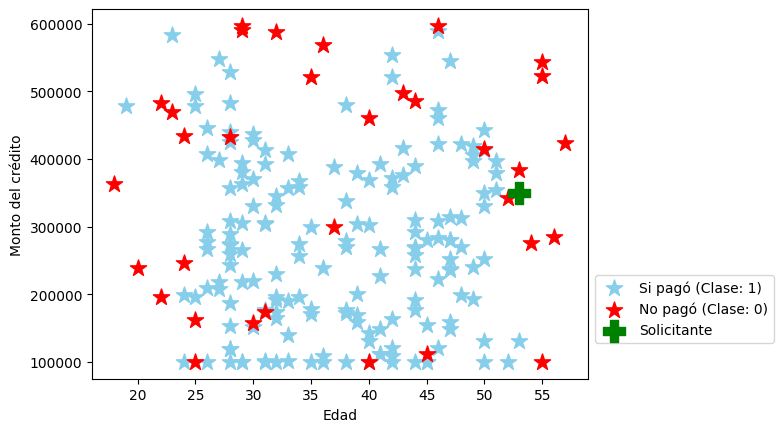

In [19]:
edad = 53
monto = 350000

solicitante = escalador.transform([[edad, monto]])
print("Clase", clasificador.predict(solicitante))
print("Probabilidades pro clase", clasificador.predict_proba(solicitante))

plt.scatter(buenos["edad"], buenos["credito"],
            marker="*", s=150, color="skyblue", label="Si pagó (Clase: 1)")
plt.scatter(malos["edad"], malos["credito"],
            marker="*", s=150, color="red", label="No pagó (Clase: 0)")
plt.scatter(edad,monto,marker="P", s=250, color="green", label="Solicitante")
plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.3))
plt.show()

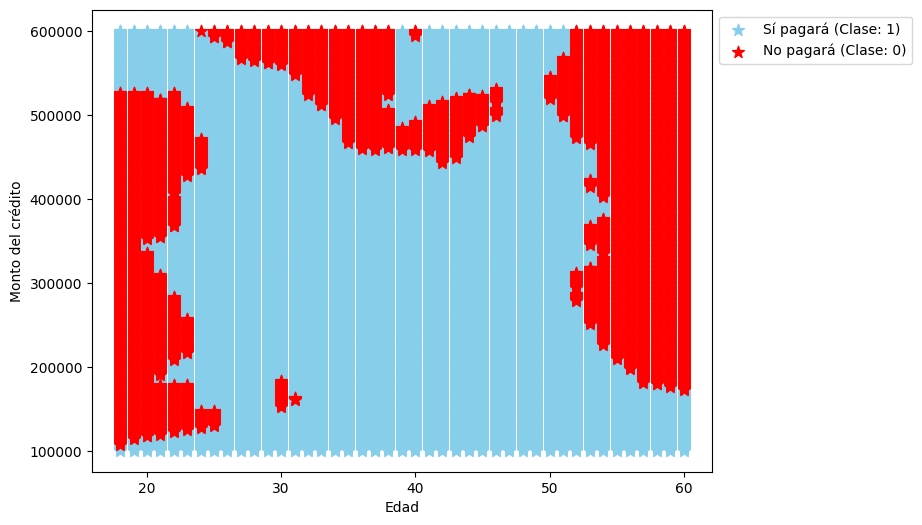

In [28]:
creditos = np.array([np.arange(100000, 600010, 1000)] * 43).reshape(1, -1)
edades = np.array([np.arange(18, 61)] * 500).reshape(1, -1)
todos = pd.DataFrame(np.stack((edades, creditos), axis=2)[0],
                     columns = ["edad", "credito"])

solicitantes = escalador.transform(todos)

clases_resultantes = clasificador.predict(solicitantes)

buenos = todos[clases_resultantes==1]
malos = todos[clases_resultantes==0]
plt.scatter(buenos["edad"], buenos["credito"],
                                 marker="*",s=150,color="skyblue", label="Si pagará(Clase: 1)")
plt.scatter(malos["edad"], malos["credito"],
                  marker="*", s=150, color="red", label="No pagará (Clase: 0)")
plt.ylabel("Monto del crédito")
plt.xlabel("Edad")
plt.legend(bbox_to_anchor=(1, 0.2))
plt.show()

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Cargar y preparar datos
clientes = pd.read_csv("/content/creditos.csv")
X = clientes[["edad", "credito"]]
y = clientes["cumplio"]

# Escalado
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

n = len(X_train)
ks = [1, 3, 5, 7, int(np.sqrt(n))]

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    print(f'k={k}, precisión={score:.3f}')
# Taller KNN - distintas distancias, matrices de confusión y varios k



# 2. Probar distintas distancias
metricas = {
    "euclidiana": {"metric": "euclidean"},
    "manhattan": {"metric": "manhattan"},
    "minkowski (p=3)": {"metric": "minkowski", "p": 3},
    # "hamming": {"metric": "hamming"}, # Removed Hamming distance
}

resultados = []

print("=== Comparación de métricas con k=3 ===\n")
for nombre, params in metricas.items():
    print("=" * 80)
    print(f"Métrica: {nombre}")
    knn = KNeighborsClassifier(n_neighbors=3, **params)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    resultados.append((nombre, 3, acc))

    print(f"Precisión: {acc:.4f}\n")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

# 3. Seleccionar la mejor métrica según accuracy
mejor_nombre, _, _ = max(resultados, key=lambda t: t[2])
print("\n\n** Mejor métrica según la precisión en test:", mejor_nombre, "**\n")

best_params = metricas[mejor_nombre]

# 4. Probar distintos k con la mejor métrica
ks = [1, 3, 5, 7, int(np.sqrt(len(X_train)))]

print(f"=== Variación de k usando la métrica {mejor_nombre} ===\n")
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, **best_params)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"k = {k:2d}  ->  precisión = {acc:.4f}")

k=1, precisión=0.800
k=3, precisión=0.800
k=5, precisión=0.817
k=7, precisión=0.800
k=11, precisión=0.800
=== Comparación de métricas con k=3 ===

Métrica: euclidiana
Precisión: 0.8000

Matriz de confusión:
[[ 2  8]
 [ 4 46]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.33      0.20      0.25        10
           1       0.85      0.92      0.88        50

    accuracy                           0.80        60
   macro avg       0.59      0.56      0.57        60
weighted avg       0.77      0.80      0.78        60

Métrica: manhattan
Precisión: 0.8167

Matriz de confusión:
[[ 3  7]
 [ 4 46]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.43      0.30      0.35        10
           1       0.87      0.92      0.89        50

    accuracy                           0.82        60
   macro avg       0.65      0.61      0.62        60
weighted avg       0.79      0.82      0.80